<a href="https://colab.research.google.com/github/GarethH123/Intelligent-Systems-Project/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Install dependencies

In [ ]:
!pip install tensorflow opencv-python matplotlib

In [ ]:
import tensorflow as tf
from tensorflow import keras
from matplotlib import pyplot as plt
%matplotlib inline
import numpy as np
import cv2
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten


2. Load Data

In [ ]:
(X_train, Y_train) , (X_test, Y_test) = keras.datasets.mnist.load_data()




#scale=1./255.
#keras.layers.Rescaling(scale, offset=0.0, X_train)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


and scale the data

In [ ]:

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [ ]:
len(X_train)

60000

In [ ]:
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

3. Preprocessing

3.1 Scaling the data Making the numbers in the data as small as possible reduces the computation.

In [ ]:
print(X_train[0])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

4.0 Buidling the model

In [ ]:
model = Sequential()

In [ ]:
#First layer is a convultion, it has 16 layers, kernel is 3 by 3, have a stride of 1
#Output from this convolution is passed through the relu, any output below 0 is converted to 0, preserve any thing above 0
#The max pool takes in the maximum value after the relu function is applied
model.add(Conv2D(16,(3,3),1, activation ='relu', input_shape = (28,28,1)))
model.add(MaxPooling2D())

#Adding double the layers
model.add(Conv2D(32,(3,3),1, activation ='relu'))
model.add(MaxPooling2D())


model.add(Conv2D(16,(3,3),1, activation ='relu'))
model.add(MaxPooling2D())

#Flatten the output to pass through the NN
model.add(Flatten())


#Dense layer is 256 neurons
#Sigmoind takes in the output and makes it result between  0 or 1
model.add(Dense(256, activation ='relu'))
model.add(Dense(10, activation="softmax"))



/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Adam is the optimiser, this quantifies how to adjust the functions to reduce the loss function
#(Adaptive Moment Estimation)


# The reason why we have a sparse categorical, is because we have multiple different category outputs from 0 to 9.
# Model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])
# Metric your goal is to make it more accurate, so when it predicates you want it to be more accurate.
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
#model.fit(X_train, Y_train, epochs=5)


In [ ]:
model.summary()
# Model shapes the code from 28 by 28 to 26by 26, 16 layers
# Max pooling layer converts it to 13 by 13 with 16 layers
# Next layer is 11 by 11
# Max pool has the image at 5 by 5
# the next layer is 3 by 3
# the max pool of that is 1 by 1 (the max pool halves the output)
# The flatten layer is 1 x 1 x 16 which is passed and flattened to the flatten layer.
# Pass it to the dense layer with 256 neurons
# Then to a single output layer

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 16)       │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,346 (63.85 KB)

 Trainable params: 16,346 (63.85 KB)

 Non-trainable params: 0 (0.00 B)

4.2 Training

In [ ]:
logdir='logs'

In [ ]:
#this will monitor the learning rate

tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [ ]:
#epoch how many full run throughs
#Valdiations data
#tensor call back
#History = hist
#hist = model.fit(X_train, Y_train, epochs=20, validation_data=(X_test, Y_test), callbacks=[tensorboard_callback])
hist = model.fit(X_train, Y_train, epochs=5, validation_data=(X_test, Y_test), callbacks=[tensorboard_callback])

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - accuracy: 0.8958 - loss: 0.3308 - val_accuracy: 0.9579 - val_loss: 0.1418
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9618 - loss: 0.1231 - val_accuracy: 0.9653 - val_loss: 0.1076
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.9714 - loss: 0.0922 - val_accuracy: 0.9773 - val_loss: 0.0719
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9760 - loss: 0.0761 - val_accuracy: 0.9782 - val_loss: 0.0724
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9800 - loss: 0.0646 - val_accuracy: 0.9762 - val_loss: 0.0790
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9828 - loss: 0.0562 - val_accuracy: 0.9798 - val_loss: 0.0647
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9844 - loss: 0.0491 - val_accuracy: 0.9779 - val_loss: 0.0787
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9865 -

4.3 Find the best model

In [ ]:
keras.callbacks.ModelCheckpoint(
    filepath='best_model.keras',
    monitor="val_loss",
    verbose=0,
    save_best_only=True,
    save_weights_only=False,
    mode="auto",
    save_freq="epoch",
    initial_value_threshold=None,
)

4.4 Plot performance

In [ ]:
hist.history

{'accuracy': [0.8957833051681519,
  0.961816668510437,
  0.9713833332061768,
  0.9759666919708252,
  0.9800166487693787,
  0.982783317565918,
  0.9843999743461609,
  0.986549973487854,
  0.9864833354949951,
  0.9886166453361511,
  0.9890333414077759,
  0.989983320236206,
  0.9909666776657104,
  0.991683304309845,
  0.9911500215530396,
  0.9923166632652283,
  0.9929500222206116,
  0.993483304977417,
  0.9934499859809875,
  0.9939333200454712],
 'loss': [0.3308185338973999,
  0.12305367738008499,
  0.09223109483718872,
  0.07611093670129776,
  0.06455817073583603,
  0.05623061582446098,
  0.04909328743815422,
  0.043774452060461044,
  0.04067157953977585,
  0.036102645099163055,
  0.033625826239585876,
  0.029662156477570534,
  0.027876654639840126,
  0.025980781763792038,
  0.025914207100868225,
  0.02330069988965988,
  0.021992111578583717,
  0.02000080980360508,
  0.019455239176750183,
  0.01780930906534195],
 'val_accuracy': [0.9578999876976013,
  0.9653000235557556,
  0.977299988269

Visualisation for Loss

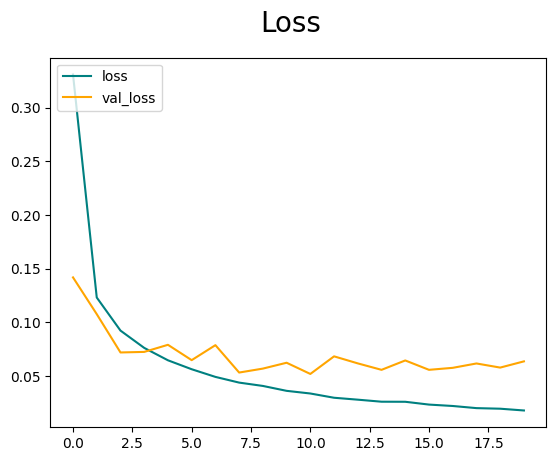

In [ ]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

Visulisation for accuracy

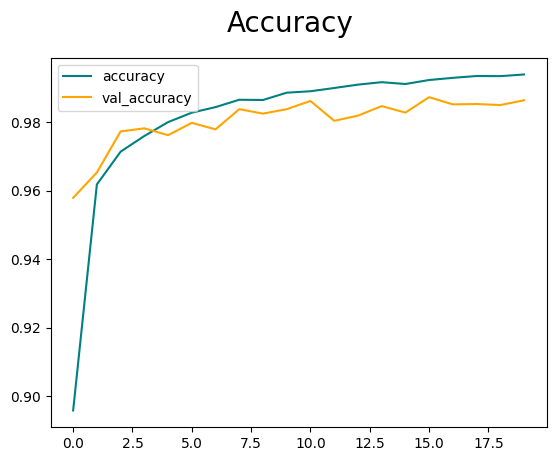

In [ ]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

5.0 Evaluate

In [ ]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [ ]:
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

In [ ]:
for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    pre.update_state(y, yhat)
    re.update_state(y, yhat)
    acc.update_state(y, yhat)

NameError: name 'test' is not defined

In [ ]:
print(pre.result(), re.result(), acc.result())

6.1 test

In [ ]:
y_predicted = model.predict(X_test)
y_predicted[1]

In [ ]:

#Compare the values.
#For each of the values test if the value is the same, if not.
#Pick the best check point from the epoch set pick the model with the lowest loss and highest accuracy.

In [ ]:
np.argmax(y_predicted[1])

In [ ]:
Y_test[1]